# Bipartite graph scratch

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import polars as pl
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
import optuna
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data, HeteroData
import networkx as nx
from torch_geometric.utils import to_networkx
import torch
from torch.nn import Linear
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATv2Conv, to_hetero, RGATConv, HeteroConv, Linear
from sklearn.manifold import TSNE
import lightning as L
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from torch.utils.data import DataLoader
from torchvision import transforms
import torch_geometric.transforms as T
import torch_geometric

from bipartite_gnn.graph_visualizatons import visualize_graph, visualize_embeddings
from baseline_evals.mlp_eval import MLP, MLPDataset, MLPTrainer

In [3]:
rna = pl.read_csv("xena_brca_data/TCGA.BRCA.sampleMap_HiSeqV2", separator="\t")

In [4]:
gene_names = rna[:,0]
rna = rna.drop("sample")

In [5]:
# load labels & filter rows with nulls
clinicalMatrix = pl.read_csv("xena_brca_data/TCGA.BRCA.sampleMap_BRCA_clinicalMatrix", separator="\t", infer_schema_length=0)
cM = clinicalMatrix.filter(pl.col("PAM50_mRNA_nature2012") != "null")

In [6]:
labels = cM.select(["sampleID","PAM50_mRNA_nature2012"])
labels = labels.filter(pl.col("PAM50_mRNA_nature2012") != "Normal-like")

In [7]:
y_all = labels["PAM50_mRNA_nature2012"].to_numpy()
# y_all

In [8]:
# display label counts
np.unique(labels["PAM50_mRNA_nature2012"].to_numpy(), return_counts=True)

(array(['Basal-like', 'HER2-enriched', 'Luminal A', 'Luminal B'],
       dtype=object),
 array([ 98,  58, 231, 127]))

In [9]:
rna = rna.select(labels["sampleID"].to_numpy())

In [10]:
# filter low var rows
rna_mat = rna.to_numpy()
rna_vars = rna_mat.var(axis=1)
high_var_mask = rna_vars > 0.1

np.unique(high_var_mask, return_counts=True)

high_var_idx = np.where(high_var_mask)[0]

gene_names = gene_names[high_var_idx]
rna = rna[high_var_idx]

print(rna.shape, gene_names.shape)

(18994, 514) (18994,)


In [11]:
label_encoder = LabelEncoder()
label_encoder.fit(y_all)
y_all_e = label_encoder.transform(y_all)

# add numberd labels to labels df
labels = labels.with_columns(y=y_all_e)

In [12]:
# labels and rna columns are aligned, do train, val, test split

# random split for train / test
train_idx, val_test_idx = train_test_split(
    np.arange(rna.shape[1]),
    test_size=0.2,
    stratify=y_all_e,
    random_state=4
)

In [13]:
val_idx, test_idx = train_test_split(
    val_test_idx, 
    test_size=0.5, 
    stratify=y_all_e[val_test_idx],                   
    random_state=4
)

In [14]:
# split dataframes
train_df = rna[:, train_idx.tolist()]
train_labels = labels[train_idx]
val_df = rna[:, val_idx.tolist()]
val_labels = labels[val_idx]
test_df = rna[:, test_idx.tolist()]
test_labels = labels[test_idx]

In [15]:
def variational_selection(X_train, y, n_features=500):
    """
    Given training data X_train (n_samples, n_features) and labels y (n_samples,)
    filter the features with class based variance
    """
    # select features based on the training set
    num_labels = len(np.unique(y))
    features_class_mean = np.zeros((X_train.shape[1], num_labels))

    # separate training samples by class
    for label in range(num_labels):
        X_class = X_train[y == label]
        features_class_mean[:, label] = X_class.mean(axis=0)

    feat_class_vars = features_class_mean.var(axis=1)
    class_var_order = np.argsort(feat_class_vars)

    # select the features with the largest variance
    best_mask = class_var_order >= (feat_class_vars.shape[0] - n_features)
    best_idx = np.where(best_mask)[0]

    return best_mask, best_idx

In [21]:
X_train = train_df.to_numpy().T
y_train = train_labels["y"].to_numpy()
X_val = val_df.to_numpy().T
y_val = val_labels["y"].to_numpy()
X_test = test_df.to_numpy().T
y_test = test_labels["y"].to_numpy()

best_500, best_500_idx = variational_selection(X_train, y_train, n_features=3000)

X_train = X_train[:, best_500]
X_val = X_val[:, best_500]
X_test = X_test[:, best_500]

best_500_genes = gene_names[best_500_idx].to_numpy()

# scale everything
std_scale = StandardScaler().fit(X_train)
X_train = std_scale.transform(X_train) 
X_val = std_scale.transform(X_val)
X_test = std_scale.transform(X_test)

In [22]:
# eval using knns
ks = (1, 30)

# eval on rbf svms
def objective_knn(trial):

    knn = KNeighborsClassifier(
        n_neighbors=trial.suggest_int("n_neighbors", ks[0], ks[1]),
        weights=trial.suggest_categorical("weights", ["uniform", "distance"]),
    )


    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_val)

    f1 = f1_score(y_val, y_pred, average="weighted")

    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective_knn, n_trials=200)

# print the mean f1 score for the best performing parameter
# print(
#     f"| RBF SVM | {best_results['acc']:.4f} +/- {best_results['acc_std']:.4f} | {best_results['f1_macro']:.4f} +/- {best_results['f1_macro_std']:.4f} | {best_results['f1_weighted']:.4f} +/- {best_results['f1_weighted_std']:.4f} |"
# )
print(f"study {study.best_value=}, {study.best_params=}")

[I 2024-04-14 16:30:19,292] A new study created in memory with name: no-name-8f5793dd-bfec-46aa-8607-aa1da1891a50
[I 2024-04-14 16:30:19,302] Trial 0 finished with value: 0.7111839575871628 and parameters: {'n_neighbors': 26, 'weights': 'distance'}. Best is trial 0 with value: 0.7111839575871628.
[I 2024-04-14 16:30:19,312] Trial 1 finished with value: 0.7118965233152084 and parameters: {'n_neighbors': 10, 'weights': 'uniform'}. Best is trial 1 with value: 0.7118965233152084.
[I 2024-04-14 16:30:19,321] Trial 2 finished with value: 0.6842148624155544 and parameters: {'n_neighbors': 20, 'weights': 'uniform'}. Best is trial 1 with value: 0.7118965233152084.
[I 2024-04-14 16:30:19,331] Trial 3 finished with value: 0.6842148624155544 and parameters: {'n_neighbors': 21, 'weights': 'uniform'}. Best is trial 1 with value: 0.7118965233152084.
[I 2024-04-14 16:30:19,340] Trial 4 finished with value: 0.7137254901960786 and parameters: {'n_neighbors': 17, 'weights': 'uniform'}. Best is trial 4 wi

study study.best_value=0.7368378129623804, study.best_params={'n_neighbors': 1, 'weights': 'distance'}


In [23]:
knn = KNeighborsClassifier(
    n_neighbors=study.best_params["n_neighbors"],
    weights=study.best_params["weights"]
)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

f1 = f1_score(y_test, y_pred, average="weighted")

print("knn f1: ", f1)

knn f1:  0.6009341535657325


## KNNs
f1 score of ~0.65

In [24]:
C_range: tuple = (1e-3, 1e3)
gamma_range: tuple = (1e-3, 1e3)

# eval on rbf svms
def objective(trial):

    svm = SVC(
        C=trial.suggest_float("C", C_range[0], C_range[1], log=True),
        gamma=trial.suggest_float(
            "gamma", gamma_range[0], gamma_range[1], log=True
        ),
        class_weight=trial.suggest_categorical("class_weight", ["balanced", None]),
        kernel="rbf",
    )

    svm.fit(X_train, y_train)
    
    y_pred = svm.predict(X_val)

    f1 = f1_score(y_val, y_pred, average="weighted")

    return f1

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200)

# print the mean f1 score for the best performing parameter
# print(
#     f"| RBF SVM | {best_results['acc']:.4f} +/- {best_results['acc_std']:.4f} | {best_results['f1_macro']:.4f} +/- {best_results['f1_macro_std']:.4f} | {best_results['f1_weighted']:.4f} +/- {best_results['f1_weighted_std']:.4f} |"
# )
print(f"study {study.best_value=}, {study.best_params=}")

[I 2024-04-14 16:30:28,423] A new study created in memory with name: no-name-c5263ece-4f0f-4eb6-82e2-4312f3e2c372


[I 2024-04-14 16:30:28,572] Trial 0 finished with value: 0.28033916269210385 and parameters: {'C': 53.67785616997287, 'gamma': 2.268266730913626, 'class_weight': None}. Best is trial 0 with value: 0.28033916269210385.
[I 2024-04-14 16:30:28,705] Trial 1 finished with value: 0.28033916269210385 and parameters: {'C': 0.001920614072353826, 'gamma': 9.236760344849017, 'class_weight': None}. Best is trial 0 with value: 0.28033916269210385.
[I 2024-04-14 16:30:28,843] Trial 2 finished with value: 0.28033916269210385 and parameters: {'C': 12.57100634744789, 'gamma': 0.024792992140932838, 'class_weight': None}. Best is trial 0 with value: 0.28033916269210385.
[I 2024-04-14 16:30:28,986] Trial 3 finished with value: 0.024767801857585137 and parameters: {'C': 0.001196606359023886, 'gamma': 0.7744797951194848, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.28033916269210385.
[I 2024-04-14 16:30:29,131] Trial 4 finished with value: 0.28033916269210385 and parameters: {'C': 403.07607031

study study.best_value=0.7015364691562105, study.best_params={'C': 107.40640120915582, 'gamma': 0.0010295785382237342, 'class_weight': 'balanced'}


In [25]:
# fit model with best params and test on test set
svm = SVC(
        C=study.best_params["C"],
        gamma=study.best_params["gamma"],
        class_weight=study.best_params["class_weight"],
        kernel="rbf",
)

svm.fit(X_train, y_train)

y_pred = svm.predict(X_test)

f1 = f1_score(y_test, y_pred, average="weighted")

print("svm f1: ", f1)

svm f1:  0.6282200860240787


## SVMs with rbf kernel
- weighted f1 score with ~0.83 on test set

# Classical neural network

In [26]:
X_train, X_val, X_test = torch.tensor(X_train), torch.tensor(X_val), torch.tensor(X_test)
y_train, y_val, y_test = torch.tensor(y_train), torch.tensor(y_val), torch.tensor(y_test)

# Convert data to torch.float32
X_train = X_train.float()
X_val = X_val.float()
X_test = X_test.float()

# Create datasets with transforms (assuming your data is suitable for ToTensor)
train_dataset = MyDataset(X_train, y_train)
val_dataset = MyDataset(X_val, y_val)
test_dataset = MyDataset(X_test, y_test)

batch_size = 32  # Adjust batch size based on your hardware and data size

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=11)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=11)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=11)

NameError: name 'MyDataset' is not defined

In [291]:
# Create model instance
model = MLP(
    input_sz=X_train.shape[1],
    num_classes=len(np.unique(y_train)),
    hidden_channels=32
)

# Create LightningModule instance
mlp = MLPTrainer(model)

# Create PyTorch Lightning Trainer
trainer = L.Trainer(
    max_epochs=40,
    log_every_n_steps=1,
    callbacks=[EarlyStopping(monitor="val_loss", mode="min")],
)

# Train the model
trainer.fit(
    model=mlp,
    train_dataloaders=train_loader,  # Fixed the argument name
    val_dataloaders=val_loader  # Added validation data
)

# Test the model
trainer.test(
    model=mlp,
    dataloaders=test_loader  # Fixed the argument name
)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/home/lubojjan/micromamba/envs/diploma/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/home/lubojjan/micromamba/envs/diploma/lib/python3.12/site-packages/lightning/pytorch/core/optimizer.py:376: Found unsupported keys in the optimizer configuration: {'lr_scheduler_config'}

  | Name | Type | Params
------------------------------
0 | net  | MLP  | 16.2 K
------------------------------


Sanity Checking: |                                                                                            …

Training: |                                                                                                   …

Validation: |                                                                                                 …

Validation: |                                                                                                 …

...

Validation: |                                                                                                 …

Validation: |                                                                                                 …

Testing: |                                                                                                    …

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
         test_f1            0.7925633192062378
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


[{'test_f1': 0.7925633192062378}]

## MLP results
so with a simple MLP we get about the same results as with rbf svm, ~
0.835

## Mogonet style gnn

In [28]:
def cosine_similarity_matrix(matrix):
    """
    given a matrix of (n_samples, n_features) compute the cosine similarities, between the samples
    """
    # Compute dot product between all pairs of vectors
    dot_products = np.dot(matrix, matrix.T)
    
    # Compute magnitudes of all vectors
    magnitudes = np.linalg.norm(matrix, axis=1)
    
    # Compute outer product of magnitudes to obtain matrix of magnitudes product
    magnitude_products = np.outer(magnitudes, magnitudes)
    
    # Compute cosine similarity matrix
    cosine_similarities = dot_products / magnitude_products
    
    return cosine_similarities

def keep_n_neighbours(A, n):
      rows, cols = A.shape
      for i in range(rows):
        # Find indices of the k highest elements
        bottom_k_indices = np.argsort(A[i])[:-n]
        # Set all other elements to zero
        A[i][bottom_k_indices] = 0
      return A
    

def dense_to_coo(adj_mat):
    """
    convert an adjacency matrix in a dense format to a torch tensor in COO format
    """
    indices = np.where(adj_mat != 0)
    indices = np.vstack((indices[0], indices[1]))
    return torch.tensor(indices, dtype=torch.int64)
    
def dense_to_attributes(adj_mat):
    """
    return the flattened weight entries from the matrix
    for use as edge attributes
    """
    return torch.tensor(adj_mat[adj_mat != 0]).view(-1,1)
    

In [29]:
from torch_geometric.nn import GCNConv


class GCN(torch.nn.Module):
    def __init__(self, input_sz, n_classes, hidden_channels):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GCNConv(input_sz, hidden_channels, add_self_loops=False)
        self.conv2 = GCNConv(hidden_channels, n_classes, add_self_loops=False)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = x.relu()
        x = F.dropout(x, p=0.2, training=self.training)
        x = self.conv2(x, edge_index)
        return x

class GAT(torch.nn.Module):
    def __init__(self, input_sz, n_classes, hidden_channels, heads):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GATv2Conv(input_sz, hidden_channels, heads, dropout=0.4, add_self_loops=False)
        self.conv2 = GATv2Conv(hidden_channels * heads, n_classes, heads=1, concat=False, dropout=0.4, add_self_loops=False)

    def forward(self, x, edge_index):
        x = F.dropout(x, p=0.4, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.4, training=self.training)
        x= self.conv2(x, edge_index)
        return x

torch.Size([514, 3000])
torch.Size([2, 4490])
num of isolated nodees 11


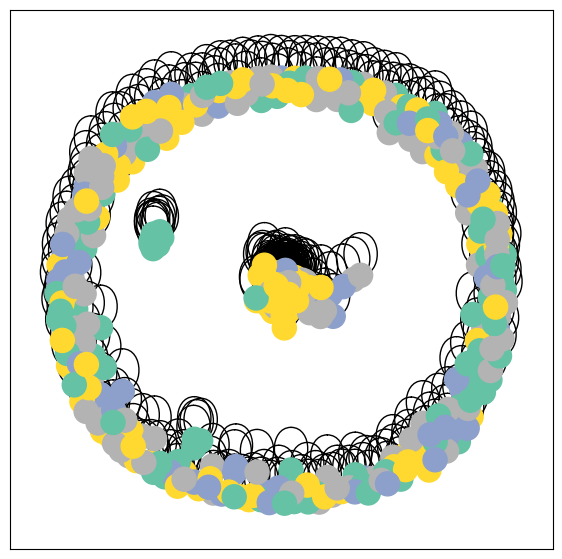

In [34]:
# build mogonet style GNN with
# a. thresholded cosine similarity

# transform features to (n_samples, n_features) tensor
X = rna.to_numpy().T
X = X[:, best_500]


# construct adjacency matrix
eps = 0.99
n = 4
A = cosine_similarity_matrix(X)
# A = keep_n_neighbours(A, n)
A[np.abs(A) < eps] = 0

X = std_scale.transform(X)
X = torch.tensor(X, dtype=torch.float32)
print(X.shape)

# construct edge indices
edge_indices = dense_to_coo(A)
print(edge_indices.shape)

# construct training mask
train_mask = np.zeros(X.shape[0], dtype=bool)
train_mask[train_idx] = True
train_mask = torch.tensor(train_mask)

val_mask = np.zeros(X.shape[0], dtype=bool)
val_mask[val_idx] = True
val_mask = torch.tensor(val_mask)

test_mask = np.zeros(X.shape[0], dtype=bool)
test_mask[test_idx] = True
test_mask = torch.tensor(test_mask)

y = torch.tensor(y_all_e, dtype=torch.int64)

data = Data(
    x=X,
    edge_index=edge_indices,
    y=y,
    train_mask=train_mask,
    val_mask=val_mask,
    test_mask=test_mask,
)

print(f"num of isolated nodees {np.sum(A.sum(axis=1) == 1)}")

G = to_networkx(data, to_undirected=True)
visualize_graph(G, color=data.y)

In [35]:
# model = GCN(
#     input_sz=X_train.shape[1],
#     n_classes=len(np.unique(y_train)),
#     hidden_channels=32,
# )
model = GAT(
    input_sz=X_train.shape[1],
    n_classes=len(np.unique(y_train)),
    hidden_channels=64,
    heads=2,
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()
# scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=50, gamma=0.25)  # Define the learning rate scheduler

def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data.x, data.edge_index)  # Perform a single forward pass.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Compute the loss solely based on the training nodes.
    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss

@torch.no_grad()
def test(mask):
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    test_correct = pred[mask] == data.y[mask]  # Check against ground-truth labels.
    test_f1 = f1_score(pred[mask], data.y[mask], average="weighted")
    test_acc = int(test_correct.sum()) / int(mask.sum())  # Derive ratio of correct predictions.
    return test_acc, test_f1

best_val_f1 = 0

for epoch in range(1, 1001):
    loss = train()
    train_eval = test(data.train_mask)
    val_eval = test(data.val_mask)
    if epoch % 50 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f} Train acc {train_eval[0]:.4f} Train f1 {train_eval[1]:.4f} Val acc {val_eval[0]:.4f} Val f1 {val_eval[1]:.4f}')
        test_acc = test(data.test_mask)
        print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')    

print("################################")
test_acc = test(data.test_mask)
print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')

Epoch: 050, Loss: 0.6279 Train acc 0.9732 Train f1 0.9734 Val acc 0.8627 Val f1 0.8627
Test Accuracy: 0.8269, test f1: 0.8326
Epoch: 100, Loss: 0.5737 Train acc 0.9708 Train f1 0.9710 Val acc 0.8627 Val f1 0.8627
Test Accuracy: 0.7885, test f1: 0.7926
Epoch: 150, Loss: 0.4730 Train acc 0.9878 Train f1 0.9879 Val acc 0.8824 Val f1 0.8812
Test Accuracy: 0.8462, test f1: 0.8430
Epoch: 200, Loss: 0.5433 Train acc 0.9903 Train f1 0.9903 Val acc 0.8824 Val f1 0.8812
Test Accuracy: 0.8269, test f1: 0.8253
Epoch: 250, Loss: 0.5669 Train acc 0.9903 Train f1 0.9903 Val acc 0.8824 Val f1 0.8812
Test Accuracy: 0.8077, test f1: 0.8134
Epoch: 300, Loss: 0.5180 Train acc 0.9878 Train f1 0.9879 Val acc 0.8824 Val f1 0.8812
Test Accuracy: 0.8462, test f1: 0.8462
Epoch: 350, Loss: 0.5230 Train acc 0.9927 Train f1 0.9927 Val acc 0.9020 Val f1 0.9007
Test Accuracy: 0.8269, test f1: 0.8256
Epoch: 400, Loss: 0.4682 Train acc 0.9927 Train f1 0.9927 Val acc 0.9216 Val f1 0.9215
Test Accuracy: 0.8269, test f1:

## gnn results
- mogonet style with gcn gets ~0.77
- mogonet style with gat gets up to 0.84, depends on params and the graph it gets initialized with, so about the same as rbf svms and mlp
- Best Epoch: **Train acc 0.9969 Train f1 0.9969 Val acc 0.8889 Val f1 0.8940
Test Accuracy: 0.8387, test f1: 0.8407**
- interestingly on regular gcn the thresholded cosine similarity graph works much better than keep n most similar neighbours one even though the graph is a lot more disconnected, with GATs we get about the same performance with both graphs
- the parameters could be tuned with optuna

In [28]:
import torch

def dense_to_coo(adj_mat):
    """
    Convert an adjacency matrix in a dense format to a torch tensor in COO format
    """
    indices = torch.nonzero(adj_mat, as_tuple=True)
    return torch.stack(indices, dim=0)

dense_to_coo(torch.tensor(
        [[1, 0, 1], [0, 1, 0], [1, 1, 1]]
))

tensor([[0, 0, 1, 2, 2, 2],
        [0, 2, 1, 0, 1, 2]])

In [36]:
def create_expression_connections(X, std_multiplier=1.0):
    """
    This function identifies and categorizes gene expression levels as 
    under-expressed (-1), over-expressed (1), or baseline (0) based on standard 
    deviation from the mean.
    
    Args:
     X (np.ndarray): A 2D NumPy array representing gene expression data, 
         with shape (samples, genes).
     std_multiplier (float, optional): A hyperparameter that scales the 
         standard deviation to define the expression bounds. Higher values will result
         in stricter bounds (std_multiplier=2.0 will consider values further than 2 sigma
         from the mean to be differential) Defaults to 1.0.
    
    Returns:
     np.ndarray: A 2D NumPy array with the same shape as X, where each element 
         indicates the expression category (-1, 0, or 1) for the corresponding 
         gene in each sample.
    """
    mean_exps = X.mean(axis=0)
    exps_std = X.std(axis=0)
    
    lb_exps = mean_exps - exps_std * std_multiplier
    ub_exps = mean_exps + exps_std * std_multiplier
    
    A_exps = np.zeros_like(X)

    mask_below = X <= lb_exps
    mask_above = X >= ub_exps
    
    A_exps[mask_below] = -1  # Set under-expressed elements
    A_exps[mask_above] = 1  # Set over-expressed elements

    return A_exps

def diff_exp_connections_nbnom(expression_vector, var_multiplier=1):
    """
    Estimate the differential expression of a gene using the negative binomial distribution.

    Args:
        expression_vector (np.ndarray): The expression vector of the gene.
        var_multiplier (int): The multiplier for the variance threshold. Default is 1.
    Returns:
        select_mask (np.ndarray): The mask of the selected samples.
    """
    if not isinstance(expression_vector, np.ndarray):
        expression_vector = np.array(expression_vector)

    # ignore all warnings
    with warnings.catch_warnings():
        # for some distributions, the fitting will fail, so ignore warnings for those
        warnings.filterwarnings("ignore")
        res = sm.NegativeBinomial(
            expression_vector, np.ones_like(expression_vector)
        ).fit(start_params=[1, 1], disp=0)

    mu = np.exp(res.params[0])
    p = 1 / (1 + mu * res.params[1])
    r = mu * p / (1 - p)

    var = r * (1 - p) / p**2
    # var = np.sqrt(var)
    # std = var # np.sqrt(var)
    mask_above = expression_vector > mu + var * var_multiplier
    mask_below = expression_vector < mu - var * var_multiplier

    return mask_below, mask_above


def create_diff_exp_connections_nbnom(X, var_multiplier=1.0):
    """
    This function identifies and categorizes gene expression levels as
    under-expressed (-1), over-expressed (1), or baseline (0) based on the negative binomial distribution.

    Args:
        X (torch.Tensor): A 2D PyTorch tensor representing gene expression data,
            with shape (samples, genes).
        var_multiplier (float, optional): A hyperparameter that scales the
            standard deviation to define the expression bounds. Higher values will result
            in stricter bounds (std_multiplier=2.0 will consider values further than 2 sigma
            from the mean to be differential) Defaults to 1.0.
    Returns:
        A (torch.Tensor): A 2D PyTorch tensor with the same shape as X, where each element
            indicates the expression category (-1, 0, or 1) for the corresponding
            gene in each sample.
        isolated_nodes_mask (torch.Tensor): A 1D PyTorch tensor indicating the indices of
            genes that are not differentially expressed.
    """

    A = torch.zeros_like(X)

    for i in range(X.shape[1]):
        mask_below, mask_above = diff_exp_connections_nbnom(X[:, i], var_multiplier)
        A[mask_below, i] = -1
        A[mask_above, i] = 1

    # isolated_nodes_mask = torch.sum(torch.abs(A), dim=1) == 0
    # A = A[~isolated_nodes_mask]

    return A  # , isolated_nodes_mask

In [37]:
from bipartite_gnn.graph_building import create_diff_exp_connections_norm, dense_to_coo

In [38]:
# build bipartite graph style GNN

# determine the expression of gene accross the population
# - if the gene is overexpressed for that sample connect with 1
# - if the gene is underexpressed connect with -1
# - else connect with 0
# the over/under expression cutoff is a parameter we will have to tune
# GATv2Conv can use edge attribute vectors, so we can place these into the vectors
# RGAT conv can also use these

# transform features to (n_samples, n_features) tensor
X = rna.to_numpy().T
X = X[:, best_500]
Xn = std_scale.transform(X)
Xt = torch.tensor(X, dtype=torch.float32)
print(X.shape)

(514, 3000)


In [40]:
A_exps = create_diff_exp_connections_norm(torch.tensor(X), train_mask=train_mask, multiplier=3.0)
# A_exps = create_expression_connections(X, std_multiplier=3.0)

# lets see if all nodes are connected
Asums = np.abs(A_exps).sum(axis=1)
# print(Asums)
print("isolated samples:", Asums[Asums == 0])
# lets see if all nodes are connected
Asums = np.abs(A_exps).sum(axis=0)
# print(Asums)
print("isolated nodes:", Asums[Asums == 0])
# we can see that the first gene doesnt have much of an differential expression
mean_connections = np.abs(A_exps).sum(axis=1)
# print("degrees:", mean_connections)
print("mean degree:", mean_connections.mean())

isolated sample nodes, isolated gene nodes, mean degree: 
tensor(3) tensor(250) tensor(26.1284, dtype=torch.float64)
isolated samples: tensor([0., 0., 0.], dtype=torch.float64)
isolated nodes: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

# note about params
- with default multiplier of 1.0 we have a pretty dense network with mean degree ~131
- with 2.0 we get a much sparser network with mean degree of ~23 and still no isolated nodes

In [41]:
# get interactions
from bipartite_gnn.preprocessing import get_gene_gene_interactions

In [42]:
interact_df = get_gene_gene_interactions(best_500_genes)

10k interactions returned, its possible that the api call didnt return all interactions


In [43]:
interactions = interact_df.select(['Official Symbol Interactor A', 'Official Symbol Interactor B'])

In [44]:
interactions

Official Symbol Interactor A,Official Symbol Interactor B
str,str
"""CAPN3""","""TTN"""
"""TGFB1I1""","""NR3C1"""
"""RGS19""","""GNAO1"""
"""RGS19""","""GNAI3"""
"""LMNA""","""LMNB1"""
…,…
"""COX15""","""ATP5H"""
"""COX15""","""SCYL2"""
"""COX15""","""RPN1"""


In [45]:
interaction_matrix = np.eye(len(best_500_genes))
gene_idx_dict = {elem: idx for idx, elem in enumerate(best_500_genes)}
nfc = 0

alias_dict = {
    "HSPA1B" : "HSPA1A",
}

for i in range(interactions.shape[0]):
    ia = interactions[i, 0]
    ib = interactions[i, 1]

    if ia == 'HSPA1B':
        ia = 'HSPA1A'
    if ib == 'HSPA1B':
        ib = 'HSPA1A'

    if ia == 'H3F3A':
        ia = 'H3F3B'
    if ib == 'H3F3A':
        ib = 'H3F3B'

    if ia == 'SMN2':
        ia = 'SMN1'
    if ib == 'SMN2':
        ib = 'SMN1'

    if ia == 'DEFA1':
        ia = 'DEFA1B'
    if ib == 'DEFA1':
        ib = 'DEFA1B'

    if ia == 'SPCS2':
        ia = 'SPC25'
    if ib == 'SPCS2':
        ib = 'SPC25'

    if ia == 'SLURP1':
        ia = 'ARSB'
    if ib == 'SLURP1':
        ib = 'ARSB'
    
    # try match a
    ia_idx = gene_idx_dict.get(ia)
    if ia_idx is None:
        aliases = interact_df[i, 'Synonyms Interactor A'].split('|')
        for a in aliases:
            ia_idx = gene_idx_dict.get(a)
            if ia_idx is not None:
                break
        if not ia_idx:
            print(f'{ia} interactor not found in input, ignoring')
            nfc += 1
            continue
    # try match b
    ib_idx = gene_idx_dict.get(ib)
    if ib_idx is None:
        aliases = interact_df[i, 'Synonyms Interactor B'].split('|')
        for a in aliases:
            ib_idx = gene_idx_dict.get(a)
            if ib_idx is not None:
                break
        if not ib_idx:
            print(f'{ib} interactor not found in input, ignoring')
            nfc += 1
            continue
        
    interaction_matrix[ia_idx,ib_idx] = 1
    interaction_matrix[ib_idx,ia_idx] = 1

interaction_connections = dense_to_coo(torch.tensor(interaction_matrix))
print(nfc, "/", interactions.shape[0], "interactions not found in input")

HIST1H3H interactor not found in input, ignoring
NOTCH1 interactor not found in input, ignoring
NOTCH1 interactor not found in input, ignoring
NOTCH1 interactor not found in input, ignoring
GIGYF1 interactor not found in input, ignoring
GIGYF1 interactor not found in input, ignoring
HBA1 interactor not found in input, ignoring
HBA1 interactor not found in input, ignoring
HBA1 interactor not found in input, ignoring
HBA1 interactor not found in input, ignoring
ATRIP interactor not found in input, ignoring
ATRIP interactor not found in input, ignoring
HSPA1A interactor not found in input, ignoring
CCL3L1 interactor not found in input, ignoring
HSPA1A interactor not found in input, ignoring
KLK3 interactor not found in input, ignoring
CCL3L1 interactor not found in input, ignoring
IPO5 interactor not found in input, ignoring
HSPA1A interactor not found in input, ignoring
RGPD5 interactor not found in input, ignoring
RGPD5 interactor not found in input, ignoring
HSPA1A interactor not found

In [46]:
X.shape

(514, 3000)

In [47]:
sample_to_gene_connections = dense_to_coo(torch.tensor(A_exps))
# sample_to_gene_connections = torch_geometric.utils.add_self_loops(sample_to_gene_connections)[0]

/tmp/ipykernel_17258/458528002.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sample_to_gene_connections = dense_to_coo(torch.tensor(A_exps))


In [48]:
# create a heterodata object with two types of nodes

proj_dim = 256

# TODO ADD AND USE EDGE ATTRIBUTES
data = HeteroData()
data['sample'].x=Xt
data.y=y
data.train_mask=train_mask
data.val_mask=val_mask
data.test_mask=test_mask
data['feature'].x=torch.zeros(Xt.shape[1], proj_dim) # <- set initial gene features to ones
data['sample', 'connected_to', 'feature'].edge_index=dense_to_coo(A_exps)
data['sample', 'connected_to', 'feature'].edge_attributes=dense_to_attributes(A_exps)
# data['feature', 'interacts_with', 'feature'].edge_index=dense_to_coo(torch.eye(proj_dim)) # interaction_connections
data['sample', 'similar_to', 'sample'].edge_index=dense_to_coo(torch.eye(Xt.shape[0]))
# data['feature', 'interacts_with', 'feature'].edge_attr= ...


data = T.ToUndirected()(data) # add backward features
# data = T.AddSelfLoops()(data)

data.num_relations = len(list(data.edge_index_dict.keys()))

/tmp/ipykernel_17258/2814415538.py:42: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(adj_mat[adj_mat != 0]).view(-1,1)


In [52]:
class BiGAT_2L(torch.nn.Module):
    def __init__(self, input_sz, n_classes, channels, heads):
        super().__init__()
        torch.manual_seed(1234567)
        self.conv1 = GATv2Conv(input_sz, channels, heads, dropout=0.1, add_self_loops=False)
        self.conv2 = GATv2Conv(channels * heads, n_classes, heads=1, concat=False, dropout=0.1, add_self_loops=False)

    def forward(self, x, edge_index):
        # x = F.dropout(x, p=0.0, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        # x = F.dropout(x, p=0.0, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class BiGAT_3L(torch.nn.Module):
    def __init__(self, input_sz, n_classes, channels, heads, proj_dim=100):
        super().__init__()
        torch.manual_seed(1234567)

        self.mrna_proj = torch.nn.Linear(data.shape[1], proj_dim)
        
        self.conv1 = GATv2Conv(input_sz * proj_dim, channels, heads, dropout=0.1, add_self_loops=False)
        self.conv2 = GATv2Conv(channels * heads, channels, heads, dropout=0.1, add_self_loops=False)
        self.conv3 = GATv2Conv(channels * heads, n_classes, heads=1, concat=False, dropout=0.1, add_self_loops=False)

    def forward(self, x, edge_index):

        x = self.mrna_proj(x)
        # x = F.dropout(x, p=0.1, training=self.training)
        x = F.elu(self.conv1(x, edge_index))
        # x = F.dropout(x, p=0.1, training=self.training)
        x = F.elu(self.conv2(x, edge_index))
        # x = F.dropout(x, p=0.1, training=self.training)
        x = self.conv3(x, edge_index)
        return x

class RBiGAT(torch.nn.Module):
    def __init__(self, input_sz, proj_dim, hidden_channels, out_channels, num_layers):
        super().__init__()

        self.proj = Linear(input_sz, proj_dim)
        
        # first layer
        self.convs = torch.nn.ModuleList()
        # self.linears = torch.nn.ModuleList()
        
        for _ in range(num_layers):
            conv = HeteroConv({
                ('sample', 'connected_to', 'feature'): GATv2Conv((-1, -1), hidden_channels[0], dropout=0.4, add_self_loops=False),
                ('sample', 'rev_connected_to', 'feature'): GATv2Conv((-1, -1), hidden_channels[0], dropout=0.4, add_self_loops=False),
                ('feature', 'interacts_with', 'feature'): GATv2Conv((-1, -1), hidden_channels[0], dropout=0.0, add_self_loops=False),
                ('sample', 'similar_to', 'sample'): GCNConv((-1), hidden_channels[0]),
            }, aggr='sum')
            self.convs.append(conv)
            # self.linears.append(
            #     Linear(-1, hidden_channels[0])
            # )

        self.lin1 = Linear(hidden_channels[0], hidden_channels[1])
        self.lin2 = Linear(hidden_channels[1], out_channels)


    def forward(self, data):

        x_dict = data.x_dict
        edge_index_dict = data.edge_index_dict

        x_dict['sample'] = F.elu(self.proj(x_dict['sample']))
        
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict)
            x_dict = {key: x.relu() for key, x in x_dict.items()}

        x_dict['sample'] = F.elu(self.lin1(x_dict['sample']))
        
        return F.elu(self.lin2(x_dict["sample"]))


class BiRGAT_homo(torch.nn.Module):

    def __init__(self, input_sz, proj_dim, hidden_channels, num_classes, num_relations) -> None:
        super().__init__()

        self.proj = Linear(input_sz, proj_dim)

        self.conv1 = RGATConv(
            in_channels=proj_dim,
            out_channels=hidden_channels[0],
            num_relations=num_relations,
            mod="f-additive"
        )
        self.conv2 = RGATConv(
            in_channels=hidden_channels[0],
            out_channels=hidden_channels[1],
            num_relations=num_relations,
            mod="f-additive"
        )
        # self.self_loop1 = Linear(proj_dim, hidden_channels[0])
        # self.self_loop2 = Linear(hidden_channels[0], hidden_channels[1])

        self.classifier = Linear(hidden_channels[1], num_classes)

    def forward(self, data):

        data = data.clone()

        # project sample nodes
        data["sample"].x = F.elu(self.proj(data["sample"].x))

        # convert to homogeneous
        data = data.to_homogeneous()

        x = data.x
        edge_index = data.edge_index
        edge_type = data.edge_type

        # run rgat layers
        x = F.elu(self.conv1(x, edge_index, edge_type)) #  + F.elu(self.self_loop1(x))
        x = F.elu(self.conv2(x, edge_index, edge_type)) #  + F.elu(self.self_loop2(x))

        # run classifier on sample nodes
        return self.classifier(x[data.node_type == 0])

In [53]:
# using the previously defined network on this graph
# model = BiGAT_2L(
#     input_sz=X_train.shape[1],
#     n_classes=len(np.unique(y_train)),
#     channels=64,
#     heads=2,
# )
# model = BiGAT_3L(
#     input_sz=X_train.shape[1],
#     n_classes=len(np.unique(y_train)),
#     channels=32,
#     heads=1,
# )

model = RBiGAT(
    input_sz=X_train.shape[1],
    proj_dim=proj_dim,
    hidden_channels=[256, 128],
    out_channels=len(np.unique(y_train)),
    num_layers=2
)

# model = BiRGAT_homo(
#     input_sz = X_train.shape[1],
#     proj_dim = proj_dim,
#     hidden_channels = [proj_dim, proj_dim//2],
#     num_classes = len(np.unique(y_train)),
#     num_relations = data.num_relations
# )

optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

def train():
    model.train()
    optimizer.zero_grad()  # Clear gradients.
    out = model(data) # ['sample']  # Perform a single forward pass.
    mask = data.train_mask
    loss = criterion(out[mask], data.y[mask])  # Compute the loss solely based on the training nodes.

    l1_loss = torch.norm(model.proj.weight, p=1) # + torch.norm(model.proj.bias, p=1)
    loss += 0.001 * l1_loss

    loss.backward()  # Derive gradients.
    optimizer.step()  # Update parameters based on gradients.
    return loss

@torch.no_grad()
def test(mask):
    model.eval()
    out = model(data) # ['sample']
    pred = out.argmax(dim=1)  # Use the class with highest probability.
    test_correct = pred[mask] == data.y[mask]  # Check against ground-truth labels.
    test_f1 = f1_score(pred[mask], data.y[mask], average="weighted")
    test_acc = int(test_correct.sum()) / int(mask.sum())  # Derive ratio of correct predictions.
    return test_acc, test_f1

best_val_f1 = 0

for epoch in range(1, 501):
    loss = train()
    train_eval = test(data.train_mask)
    val_eval = test(data.val_mask)
    if epoch % 5 == 0:
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f} Train acc {train_eval[0]:.4f} Train f1 {train_eval[1]:.4f} Val acc {val_eval[0]:.4f} Val f1 {val_eval[1]:.4f}')
        test_acc = test(data.test_mask)
        print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')    

print("################################")
test_acc = test(data.test_mask)
print(f'Test Accuracy: {test_acc[0]:.4f}, test f1: {test_acc[1]:.4f}')

Epoch: 005, Loss: 8.0936 Train acc 0.4501 Train f1 0.6208 Val acc 0.4510 Val f1 0.6216
Test Accuracy: 0.4423, test f1: 0.6133
Epoch: 010, Loss: 7.8237 Train acc 0.4574 Train f1 0.6199 Val acc 0.4706 Val f1 0.6213
Test Accuracy: 0.4423, test f1: 0.6133
Epoch: 015, Loss: 7.5294 Train acc 0.6107 Train f1 0.7349 Val acc 0.6471 Val f1 0.7739
Test Accuracy: 0.6346, test f1: 0.7639
Epoch: 020, Loss: 7.2181 Train acc 0.6253 Train f1 0.7443 Val acc 0.6471 Val f1 0.7835
Test Accuracy: 0.6538, test f1: 0.7618
Epoch: 025, Loss: 6.9029 Train acc 0.6715 Train f1 0.7541 Val acc 0.6863 Val f1 0.7816
Test Accuracy: 0.6731, test f1: 0.7642
Epoch: 030, Loss: 6.5883 Train acc 0.7226 Train f1 0.7820 Val acc 0.6667 Val f1 0.7531
Test Accuracy: 0.6923, test f1: 0.7699
Epoch: 035, Loss: 6.3169 Train acc 0.7713 Train f1 0.8122 Val acc 0.7451 Val f1 0.7976
Test Accuracy: 0.7500, test f1: 0.7924
Epoch: 040, Loss: 6.0429 Train acc 0.7543 Train f1 0.7914 Val acc 0.6863 Val f1 0.7628
Test Accuracy: 0.7115, test f1:

# bipartite model results
without interactions it reaches 
- acc 0.47, f1 0.62 w self-loops
- acc 0.51, f1 0.64 w/o self-loops

2 layer gat with interactions and self-loops reaches
- up to acc 0.83, f1 0.83
- **Best Epoch** Train acc 0.9938 Train f1 0.9938 Val acc 0.8611 Val f1 0.8724
Test Accuracy: 0.8194, test f1: 0.8316

3 layer relational gat with interactions and self-loops can get reliably to something like
- Epoch: 280, Loss: 0.0937 Train acc 0.9907 Train f1 0.9907 Val acc 0.8611 Val f1 0.8657
Test Accuracy: 0.8323, test f1: 0.8341
- Epoch: 480, Loss: 0.0148 Train acc 1.0000 Train f1 1.0000 Val acc 0.8333 Val f1 0.8424
Test Accuracy: 0.8516, test f1: 0.8533


4 layer relational gat works well too
- Epoch: 140, Loss: 0.0868 Train acc 0.9876 Train f1 0.9876 Val acc 0.8611 Val f1 0.8634
Test Accuracy: 0.8323, test f1: 0.8325


**projection from 5000 genes to 128**  
Epoch: 645, Loss: 0.8320 Train acc 1.0000 Train f1 1.0000 Val acc 0.9444 Val f1 0.9460
Test Accuracy: 0.8645, test f1: 0.8642

**projection from 5000 genes to 256**  
Epoch: 495, Loss: 1.4109 Train acc 1.0000 Train f1 1.0000 Val acc 0.9167 Val f1 0.9187
Test Accuracy: 0.8839, test f1: 0.8844

## notes:
- ones in feature vectors seem to be better than zeros
- self loops seem to help too
- not really a big difference between 3 layer and 2 layer architecture, though 3 layer should work better from theoretical prespective as all LSPs in the graph should be 3 hops
- using more dropout in the architecture could be potentially benefitial but it takes longer to learn with that
- edge attributes dont seem to cause a big difference
- bipartite architecture seems to learn slower than mogonet-type architecture, but reaches similar performance
- relational bipartite architecture learns fast and reaches similar or better performance

In [ ]:
# a. w interactions

In [ ]:
# b. w/o interactions

In [ ]:
# bipartite style model with 2 different relations
# - sample-feature or feature-sample
# - feature-feature

In [ ]:
# eval mogonet style model


In [ ]:
# eval bipartite style model
